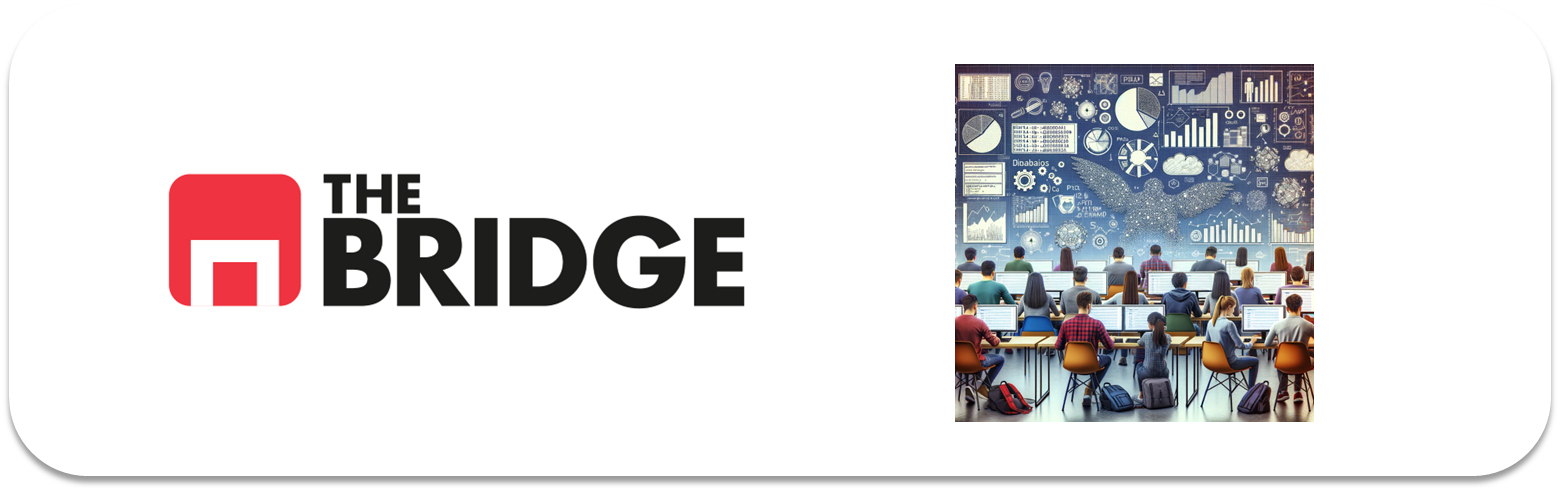

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
9. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
10. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
11. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [21]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import Ridge

In [ ]:
df = pd.read_csv("data/hard_to_find/obligatoria_hard.csv", sep="|")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


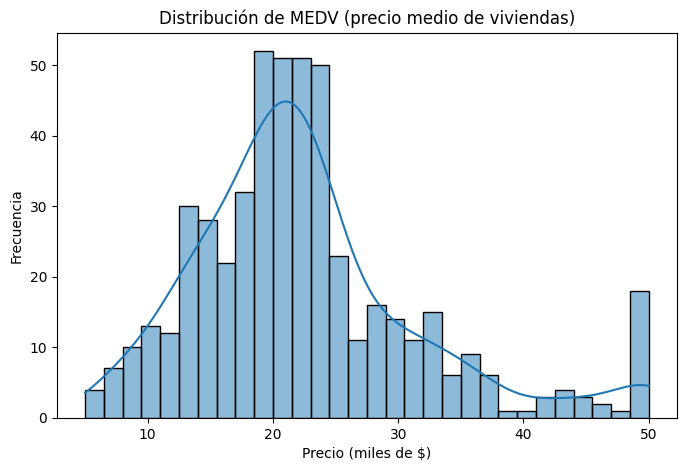

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=30, kde=True)
plt.title("Distribución de MEDV (precio medio de viviendas)")
plt.xlabel("Precio (miles de $)")
plt.ylabel("Frecuencia")
plt.show()

Se escoge MEDV como variable target porque es una variable continua numérica. Su histograma muestra una distribución unimodal, con ligera asimetría a la derecha y cierta acumulación en valores altos, especialmente cerca de 50. Aun así, su naturaleza cuantitativa la hace adecuada para aplicar un modelo de regresión.

In [6]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Se separan las features (X) y el target (y = MEDV). Posteriormente, se realiza una partición en conjuntos de entrenamiento y test utilizando un 80% de los datos para entrenamiento y un 20% para test. Se fija una semilla aleatoria para garantizar la reproducibilidad de los resultados.

In [7]:
X_train.shape, X_test.shape

((404, 12), (102, 12))

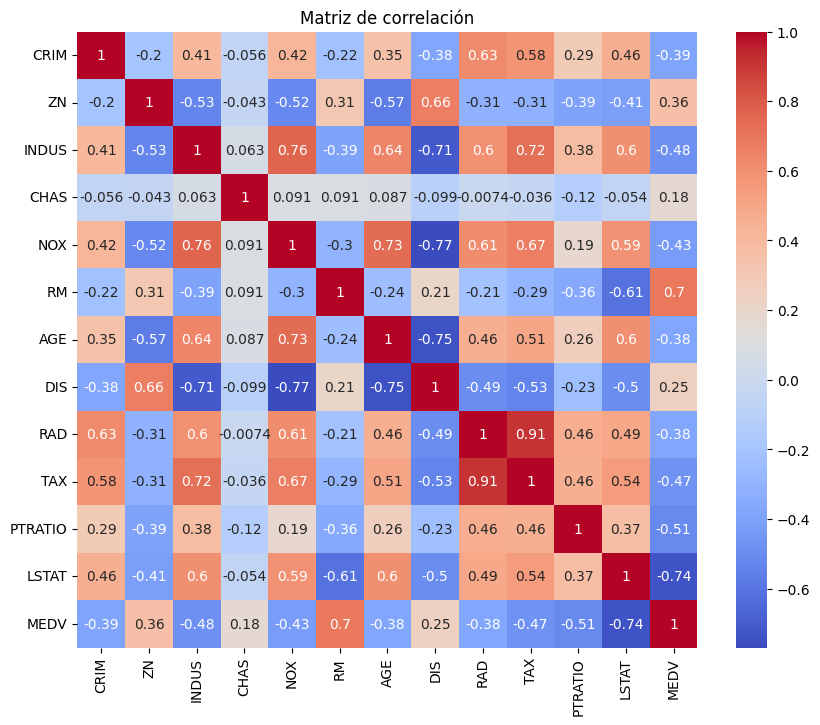

In [8]:
#relación de features con target (Mini EDA)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

LSTAT presenta una fuerte correlación negativa con el target, mientras que RM muestra una correlación positiva elevada, siendo ambas variables especialmente relevantes.

También se detecta una alta correlación entre RAD y TAX, lo que indica posible multicolinealidad. Para evitar redundancia en el modelo, se elimina RAD.

El resto de variables se mantienen, ya que aportan información relevante al modelo.

In [ ]:
X = df.drop(["RAD"], axis=1)

In [11]:
#Escalado variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#Modelo de regresión lineal

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
#predicciones

y_pred = model.predict(X_test_scaled)

In [17]:
coeficientes = pd.DataFrame({
    "feature": X_train.columns,
    "coeficiente": model.coef_
})

coeficientes = coeficientes.sort_values(by="coeficiente", ascending=False)
coeficientes

,feature,coeficiente
5,RM,3.004420
8,RAD,2.058898
3,CHAS,0.787152
1,ZN,0.712109
2,INDUS,0.173858
6,AGE,-0.100500
0,CRIM,-1.127473
9,TAX,-1.871317
10,PTRATIO,-1.991871
4,NOX,-2.137599


Las variables con mayor impacto en la predicción son LSTAT y RM. RM presenta una relación positiva con el precio de la vivienda, indicando que a mayor número de habitaciones, mayor valor. LSTAT muestra una fuerte relación negativa, siendo la variable más influyente, lo que sugiere que un mayor porcentaje de población de bajo estatus socioeconómico reduce significativamente el precio.

Otras variables relevantes incluyen DIS, NOX y PTRATIO, que también presentan efectos negativos, así como RAD y CHAS, con impacto positivo.

In [19]:
#Evaluación modelo

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, mse, rmse, r2

(3.111377388238187,
 22.777708563866035,
 np.float64(4.772599769922682),
 0.689396788461476)

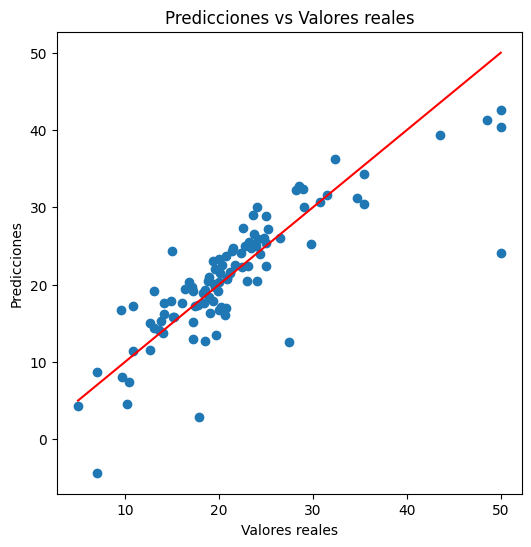

In [20]:
#comparación gráfica

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores reales")

# línea perfecta
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

El modelo muestra un buen ajuste general, con predicciones cercanas a los valores reales, aunque con cierta pérdida de precisión en valores extremos, lo que es consistente con las limitaciones de un modelo lineal.

In [22]:
#modelo regularización

alphas = [0.1, 1, 10]

for alpha in alphas:
    model_ridge = Ridge(alpha=alpha)
    model_ridge.fit(X_train_scaled, y_train)
    
    y_pred_ridge = model_ridge.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred_ridge)
    mse = mean_squared_error(y_test, y_pred_ridge)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_ridge)
    
    print(f"Alpha: {alpha}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.2f}")
    print("-"*30)

Alpha: 0.1
MAE: 3.11
RMSE: 4.77
R2: 0.69
------------------------------
Alpha: 1
MAE: 3.11
RMSE: 4.78
R2: 0.69
------------------------------
Alpha: 10
MAE: 3.09
RMSE: 4.81
R2: 0.69
------------------------------


Ambos modelos presentan resultados muy similares, por lo que se opta por la regresión lineal simple debido a su menor complejidad e interpretabilidad. La regularización no aporta mejoras significativas, lo que indica que el modelo generaliza correctamente.